In [1]:
from pathlib import Path

from ase.io import read
from ase import Atoms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("../mpl_themes/jvc.mplstyle")

O objetivo deste Jupyter Notebook será o de analisar a composição do dataset utilizado pra produzir as bandas do modelo007, no qual utilizou-se alguns subsets e um filtro de força de 20 e $\text{eV}/\AA$.

<!-- <div align="center"> -->

<!-- 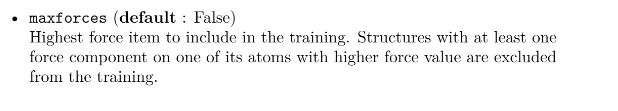 -->

<!-- </div> -->

In [2]:
# Paths
# train        = 6254 estruturas (Original Sampling)
# subset1      = 221  (1x1x8)
# subset2      = 49   (2x1x4)
# subset3      = 78   (3x3x3)
# normal_modes = 10
# -----------------------------------
# 6612 estruturas.

data = Path("/home/jvc/ZnO_database/data")

train = data / "dataset" / "01_LDA_dataset_filtered" / "train"
subsets_names = [
    "LDA_118_XSF",
    "LDA_214_XSF",
    "LDA_333_XSF",
    "LDA_normal_modes_3x3x3",
]

subsets: list[Path] = [data / f"subsets/{s}" for s in subsets_names]
xsf_dirs: list[Path] = [train, *subsets]
all_files: list[Path] = [file for d in xsf_dirs for file in sorted(d.glob("*.xsf"))]
atoms = [read(f) for f in all_files]

In [3]:
print(*all_files[:5], sep="\n")
print(len(all_files))

/home/jvc/ZnO_database/data/dataset/01_LDA_dataset_filtered/train/LDA-0001-ZnO-111-fa0.90-fc0.90-n0.000.xsf
/home/jvc/ZnO_database/data/dataset/01_LDA_dataset_filtered/train/LDA-0003-ZnO-113-fa0.90-fc0.90-n0.000.xsf
/home/jvc/ZnO_database/data/dataset/01_LDA_dataset_filtered/train/LDA-0005-ZnO-212-fa0.90-fc0.90-n0.000.xsf
/home/jvc/ZnO_database/data/dataset/01_LDA_dataset_filtered/train/LDA-0007-ZnO-221-fa0.90-fc0.90-n0.000.xsf
/home/jvc/ZnO_database/data/dataset/01_LDA_dataset_filtered/train/LDA-0009-ZnO-311-fa0.90-fc0.90-n0.000.xsf
5301


In [4]:
def get_force_df(atoms: list[Atoms], filenames: list[Path]) -> pd.DataFrame:
    """Return a long dataframe containing all the forces acting on a list of atoms."""

    dados_forcas = []

    for i, snapshot in enumerate(atoms):
        forces = snapshot.get_forces()

        for idx_atomo, vetor_forca in enumerate(forces):
            symbols: list[str] = snapshot.get_chemical_symbols()
            dados_forcas.append({
                "filename": filenames[i].name,  # Número do snapshot (0, 1, 2...)
                "atom": symbols[idx_atomo],  # Índice do átomo dentro do frame
                "fx": vetor_forca[0],
                "fy": vetor_forca[1],
                "fz": vetor_forca[2],
            })

    df_forcas = pd.DataFrame(dados_forcas)
    return df_forcas

In [5]:
forces = get_force_df(atoms=atoms, filenames=all_files)

# Filtro do aenet-PyTorch
forces["atomo_valido"] = (forces.iloc[:, 2:].abs() <= 20).all(axis=1)

print("Amostra do Dataframe filtrando por força no átomo:\n")
display(forces.sample(10))

df_estruturas = forces.groupby("filename")[["atomo_valido"]].all().reset_index()
df_estruturas = df_estruturas.rename(columns={"atomo_valido": "estrutura_valida"})

print("Amostra do Dataframe filtrando por estrutura válida:\n")
display(df_estruturas)

Amostra do Dataframe filtrando por força no átomo:



,filename,atom,fx,fy,fz,atomo_valido
111852,LDA-0077-ZnO-333-fa1.09-fc1.07-n0.000.xsf,Zn,0.000105,-0.000063,0.545007,True
22014,LDA-1416-ZnO-321-fa1.08-fc1.08-n0.000.xsf,O,-0.000203,-0.000252,7.251358,True
1338,LDA-0091-ZnO-331-fa0.90-fc1.02-n0.000.xsf,O,0.000000,-0.000000,-18.081058,True
99307,LDA-0125-ZnO-118-fa1.00-fc1.04-n0.000.xsf,O,0.000000,0.000000,-6.739332,True
7514,LDA-0491-ZnO-312-fa0.96-fc0.98-n0.000.xsf,O,-0.000350,-0.000203,11.495877,True
63968,LDA-4157-ZnO-312-fa1.04-fc0.90-n0.060.xsf,Zn,26.658599,19.441201,34.212975,False
105756,LDA-0014-ZnO-333-fa0.97-fc1.05-n0.000.xsf,Zn,0.000000,0.000000,17.004400,True
18539,LDA-1183-ZnO-331-fa1.06-fc0.94-n0.000.xsf,O,-0.000035,0.000021,9.697554,True
68888,LDA-4472-ZnO-331-fa1.08-fc0.94-n0.060.xsf,Zn,-29.376511,17.126151,17.560678,False
58576,LDA-3794-ZnO-313-fa0.98-fc1.00-n0.060.xsf,Zn,54.886921,14.731370,16.042622,False


Amostra do Dataframe filtrando por estrutura válida:



,filename,estrutura_valida
0,LDA-0001-ZnO-111-fa0.90-fc0.90-n0.000.xsf,False
1,LDA-0001-ZnO-118-fa0.90-fc0.90-n0.000.xsf,True
2,LDA-0001-ZnO-214-fa0.95-fc0.95-n0.000.xsf,True
3,LDA-0001-ZnO-333-fa0.95-fc0.95-n0.000.xsf,True
4,LDA-0002-ZnO-118-fa0.90-fc0.90-n0.040.xsf,False
...,...,...
5296,LDA-6288-ZnO-311-fa1.10-fc1.10-n0.120.xsf,False
5297,LDA-6289-ZnO-312-fa1.10-fc1.10-n0.120.xsf,False
5298,LDA-6290-ZnO-313-fa1.10-fc1.10-n0.120.xsf,False
5299,LDA-6291-ZnO-321-fa1.10-fc1.10-n0.120.xsf,False


In [6]:
df_estruturas["estrutura_valida"] = df_estruturas["estrutura_valida"].map({
    True: "sim",
    False: "não",
})
display(df_estruturas)

,filename,estrutura_valida
0,LDA-0001-ZnO-111-fa0.90-fc0.90-n0.000.xsf,não
1,LDA-0001-ZnO-118-fa0.90-fc0.90-n0.000.xsf,sim
2,LDA-0001-ZnO-214-fa0.95-fc0.95-n0.000.xsf,sim
3,LDA-0001-ZnO-333-fa0.95-fc0.95-n0.000.xsf,sim
4,LDA-0002-ZnO-118-fa0.90-fc0.90-n0.040.xsf,não
...,...,...
5296,LDA-6288-ZnO-311-fa1.10-fc1.10-n0.120.xsf,não
5297,LDA-6289-ZnO-312-fa1.10-fc1.10-n0.120.xsf,não
5298,LDA-6290-ZnO-313-fa1.10-fc1.10-n0.120.xsf,não
5299,LDA-6291-ZnO-321-fa1.10-fc1.10-n0.120.xsf,não


In [7]:
df_validas = df_estruturas.query("estrutura_valida == 'sim' ")
df_validas = df_validas.reset_index(drop=True)
display(df_validas)

,filename,estrutura_valida
0,LDA-0001-ZnO-118-fa0.90-fc0.90-n0.000.xsf,sim
1,LDA-0001-ZnO-214-fa0.95-fc0.95-n0.000.xsf,sim
2,LDA-0001-ZnO-333-fa0.95-fc0.95-n0.000.xsf,sim
3,LDA-0002-ZnO-214-fa0.95-fc0.97-n0.000.xsf,sim
4,LDA-0002-ZnO-333-fa0.95-fc0.97-n0.000.xsf,sim
...,...,...
1207,LDA-4707-ZnO-111-fa1.10-fc1.10-n0.060.xsf,sim
1208,LDA-4711-ZnO-212-fa1.10-fc1.10-n0.060.xsf,sim
1209,LDA-5968-ZnO-111-fa1.06-fc1.06-n0.120.xsf,sim
1210,LDA-6111-ZnO-111-fa1.08-fc1.06-n0.120.xsf,sim


In [8]:
count_estruturas = df_estruturas["estrutura_valida"].value_counts()
count_estruturas.index = ("Invalid", "Valid")

print(f"Contagem estruturas:\n{count_estruturas}\n")


Contagem estruturas:
Invalid    4089
Valid      1212
Name: count, dtype: int64



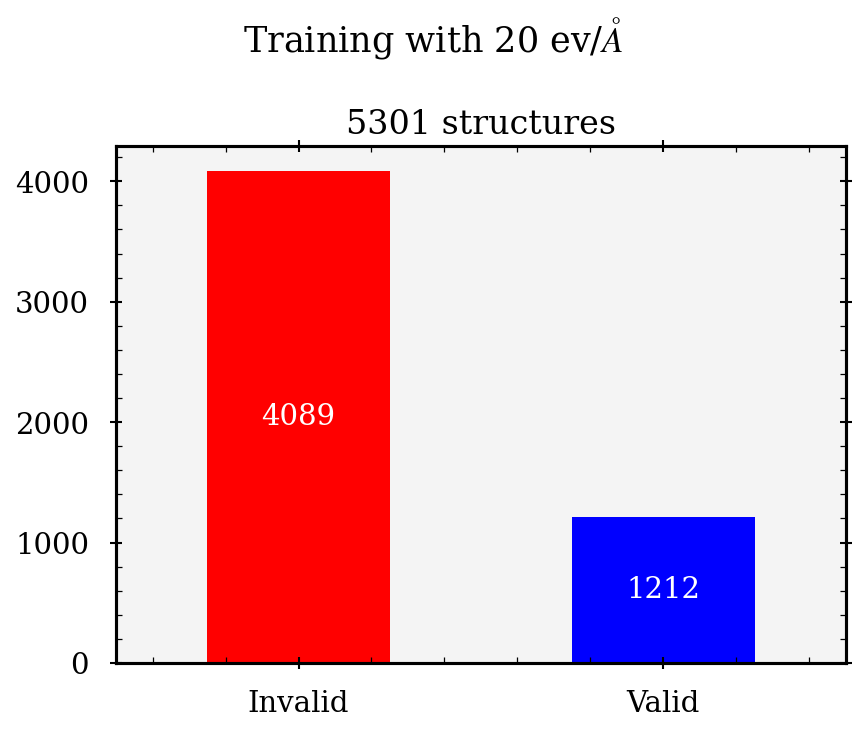

In [9]:
fig, ax = plt.subplots()
fig.suptitle(r"Training with 20 ev/$\AA$")
ax.set_title(f"{df_estruturas.shape[0]} structures")
ax.set_facecolor("#f4f4f4")
count_estruturas.plot(kind="bar", ax=ax, rot=0, color=["red", "blue"])
ax.bar_label(container=ax.containers[0], label_type="center", color="white")
ax.tick_params(direction="inout")
plt.show()

## Análise do dataset filtrado em 20 eV /$\AA$

Responderemos as seguintes perguntas para analisar o dataset utilizado para dispersão de fônons com o **model006**.

- Qual a contagem do fatores de strain $f_a$ ? E $f_c$ ?
    - Levar em consideração que são "errados" com base na análise acima.
- Qual a contribuição de cada $\sigma$? 
- Existe alguma distinção a nível do tamanho da supercélula?? 



In [21]:
df_validas["shape"] = df_validas["filename"].apply(lambda x: x.split("-")[3])
df_validas["shape"] = df_validas["shape"].apply(lambda x: "x".join(x))

df_validas["fa"] = (
    df_validas["filename"].apply(lambda x: x.split("-")[4][2:]).astype(float)
)
df_validas["fc"] = (
    df_validas["filename"].apply(lambda x: x.split("-")[5][2:]).astype(float)
)
df_validas["sigma"] = (
    df_validas["filename"].apply(lambda x: x.split("-")[6][1:-4]).astype(float)
)  # remove sufixo e '.' (-4) e n [1:
df_validas

,filename,estrutura_valida,shape,fa,fc,sigma
0,LDA-0001-ZnO-118-fa0.90-fc0.90-n0.000.xsf,sim,1x1x8,0.90,0.90,0.00
1,LDA-0001-ZnO-214-fa0.95-fc0.95-n0.000.xsf,sim,2x1x4,0.95,0.95,0.00
2,LDA-0001-ZnO-333-fa0.95-fc0.95-n0.000.xsf,sim,3x3x3,0.95,0.95,0.00
3,LDA-0002-ZnO-214-fa0.95-fc0.97-n0.000.xsf,sim,2x1x4,0.95,0.97,0.00
4,LDA-0002-ZnO-333-fa0.95-fc0.97-n0.000.xsf,sim,3x3x3,0.95,0.97,0.00
...,...,...,...,...,...,...
1207,LDA-4707-ZnO-111-fa1.10-fc1.10-n0.060.xsf,sim,1x1x1,1.10,1.10,0.06
1208,LDA-4711-ZnO-212-fa1.10-fc1.10-n0.060.xsf,sim,2x1x2,1.10,1.10,0.06
1209,LDA-5968-ZnO-111-fa1.06-fc1.06-n0.120.xsf,sim,1x1x1,1.06,1.06,0.12
1210,LDA-6111-ZnO-111-fa1.08-fc1.06-n0.120.xsf,sim,1x1x1,1.08,1.06,0.12


### Qual a contribuição de cada strain ?

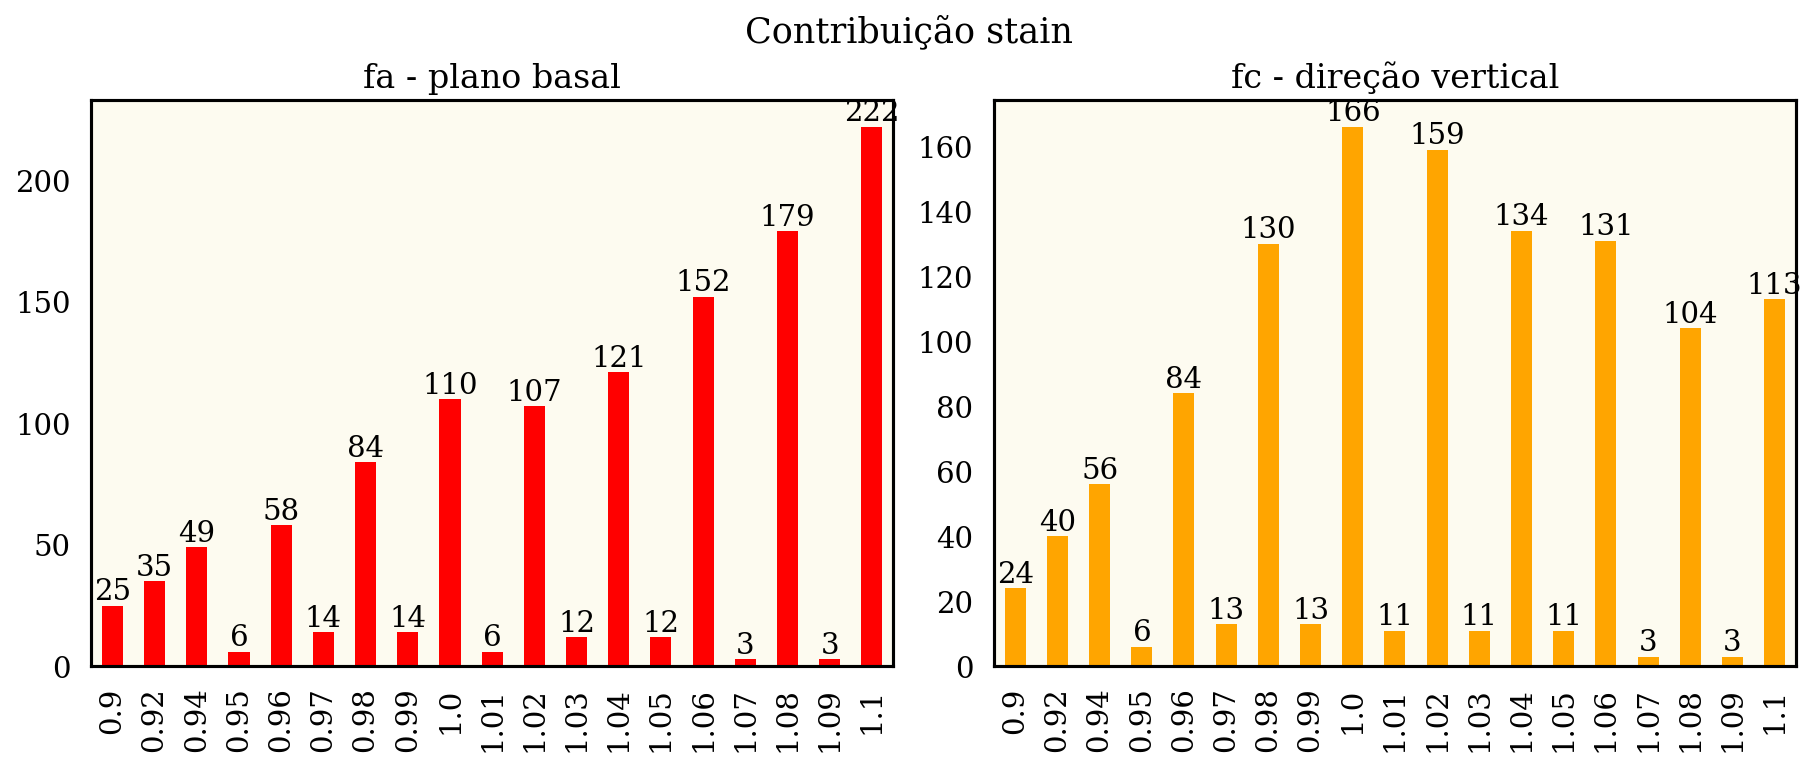

In [22]:
fig, (ax1, ax2) = plt.subplots(figsize=(12, 5), ncols=2, layout="constrained")
fig.suptitle("Contribuição stain")
ax1.set_title("fa - plano basal")
ax2.set_title("fc - direção vertical")

df_validas.groupby("fa")["filename"].count().plot(
    kind="bar", ax=ax1, rot=90, color="red"
)
df_validas.groupby("fc")["filename"].count().plot(
    kind="bar", ax=ax2, rot=90, color="orange"
)

for ax in (ax1, ax2):
    ax.tick_params(axis="both", which="both", length=0)
    ax.bar_label(ax.containers[0], color="black")
    ax.set_xlabel("")
plt.show()


Bom, aqui tirando as barrinhas pequenas com valores ímpares de $fa$ e $fc$  ue eu produzi já na fase da criação de subset para ajeitar os fônons:

- para o $fa$ é uma crescente ↗️.
- para o $fc$ o comportamento é diferente


Mas vale pontuar que, por conta do strain "estranho" não necessariamente o $fc$ pode equivaler ao strain real aplicado a vetor $c$ da rede. Com o $a$ e $b$ do plano, pelo menos, isso é garantia!



### Qual a contribuição de cada ruído aleatório??

In [23]:
count_by_sigma = df_validas.groupby("sigma")[["filename"]].count()
display(count_by_sigma)


,filename
sigma,
0.00,970
0.04,186
0.06,53
0.12,3


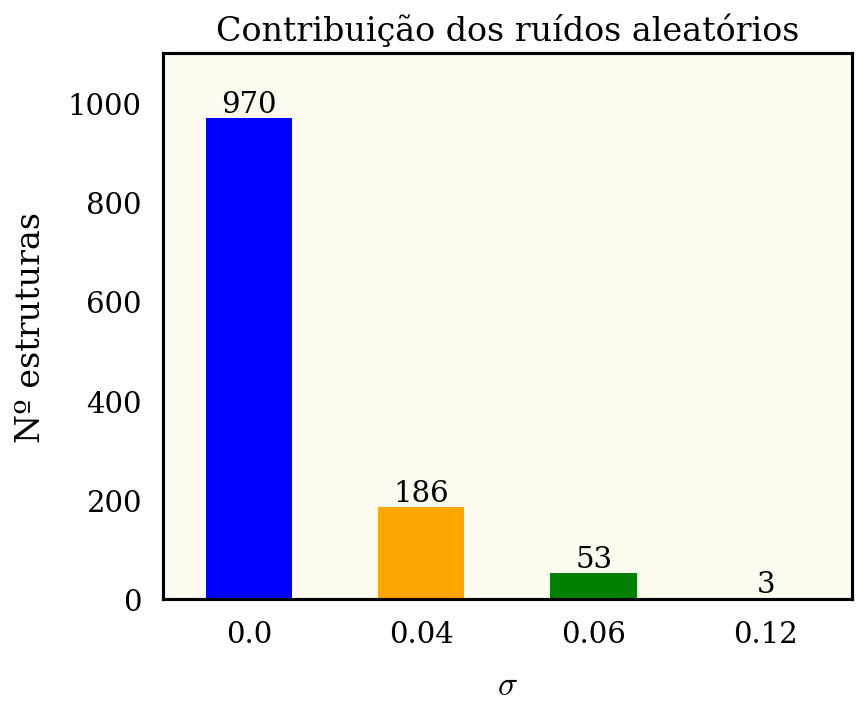

In [24]:
cores = ["blue", "orange", "green", "red"]

fig, ax = plt.subplots()
ax.set_title("Contribuição dos ruídos aleatórios")

count_by_sigma["filename"].plot(ax=ax, kind="bar", color=cores, rot=0)

ax.bar_label(ax.containers[0], color="black")
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel("Nº estruturas")
ax.set_ylim([0, 1100])
ax.tick_params(axis="both", which="both", length=0)
plt.show()

Percebe-se que para o filtro, os delocamentos aleatórios **REALMENTE** impactam nas forças. O valor de $0.12$ ficou com apenas **3 estruturas**.

## Contagem por tamanho da supercélula

In [25]:
count_by_shape = df_validas.groupby("shape")[["filename"]].count()

count_by_shape = count_by_shape.rename(columns={"filename": "contagem"})
count_by_shape = count_by_shape.sort_values(by="contagem", ascending=True)
count_by_shape

,contagem
shape,
2x1x4,41
3x3x3,50
1x1x8,66
3x1x3,66
2x1x3,72
2x2x2,72
3x3x1,73
3x1x2,75
2x2x1,76


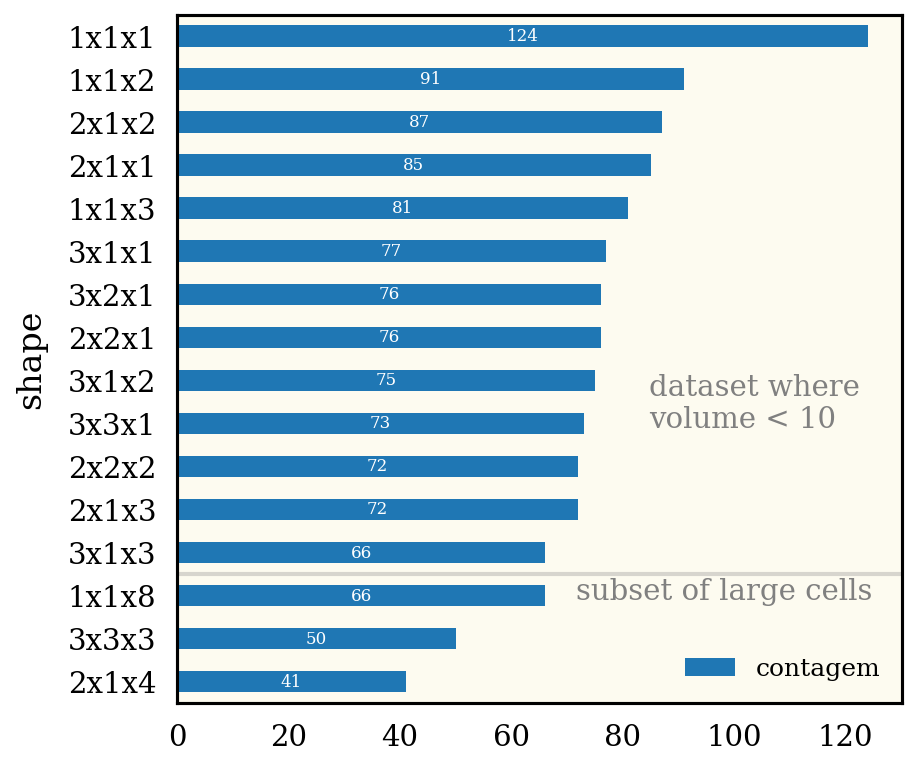

In [26]:
fig, ax = plt.subplots(layout="constrained")
count_by_shape.plot(ax=ax, kind="barh")
ax.tick_params(axis="both", which="both", length=0)
ax.bar_label(ax.containers[0], label_type="center", size=8, color="white")

ax.axhline(2.5, **lines_style)
ax.text(transform=ax.transAxes, x=0.65, y=0.4, s="dataset where\nvolume < 10", color="gray")
ax.text(transform=ax.transAxes, x=0.55, y=0.15, s="subset of large cells", color="gray")
plt.show()

Não há uma tendência/bias aparente no tamanho da supercélulas.. exceto pelas 1x1x1 que conta com mais contribuições.